In [ ]:
# --- Setup (roda sozinho; necessário só no Google Colab) ---
import os, sys
if "google.colab" in sys.modules and not os.path.exists("LAB"):
    !git clone -q https://github.com/pemodest0/Low-energy-scattering.git LAB
if os.path.exists("LAB"):
    sys.path.insert(0, "LAB")
else:
    sys.path.insert(0, os.path.abspath(".."))   # rodando localmente
print("setup ok")

# Rumo ao Efimov — a ponte do laboratório para o seu mestrado

**Para: Pedro.** Tudo que fizemos até aqui foi física de **2 corpos**.
Seu mestrado é sobre o que acontece com **3 corpos** quando o 2-corpos
está no regime que aprendemos a sintonizar: $|a| \gg$ alcance.
Este notebook conecta as duas pontas — com contas suas para rodar.

Roteiro: (1) o que é o efeito Efimov; (2) a escala mágica 22,7;
(3) o cenário de Efimov num desenho; (4) o ³⁹K de verdade: girando o
campo magnético do laboratório da Patrícia até o primeiro trímero.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from src import espalhamento, feshbach as fb
from src.potenciais import Gaussiano
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
print('pronto!')

pronto!


---
## 1. O efeito Efimov em uma conversa

Em 1970, Vitaly Efimov previu algo bizarro: quando o sistema de DOIS
corpos está exatamente no limiar ($|a| \to \infty$, a "parede" que vimos
na Fig. 10), o sistema de TRÊS corpos ganha uma **torre infinita de
estados ligados** — mesmo que dois corpos sozinhos não liguem!

$$\boxed{\;\frac{E_{n+1}}{E_n} = e^{-2\pi/s_0} \approx \frac{1}{515{,}03}, \qquad s_0 \approx 1{,}00624\;}$$

🗣️ **Tradução:** cada trímero da torre é ~515 vezes MAIS FRACO e
$e^{\pi/s_0} \approx 22{,}69$ vezes MAIOR que o anterior. É uma
**escala geométrica discreta** — um fractal quântico. O número
$s_0 = 1{,}00624$ é universal para três bósons idênticos: não depende
do átomo, do potencial, de nada.

Por que isso é surreal: nada na equação de Schrödinger de 3 corpos tem
um "fator 22,7" — ele **emerge** da física de escala no regime
$|a| = \infty$. É o exemplo mais limpo de universalidade além do que
vimos (que era só $a$ e $r_0$).

razão de energias : 515.03  (cada nível ~515x mais fraco)
razão de tamanhos : 22.694  (cada trímero ~22,7x maior)


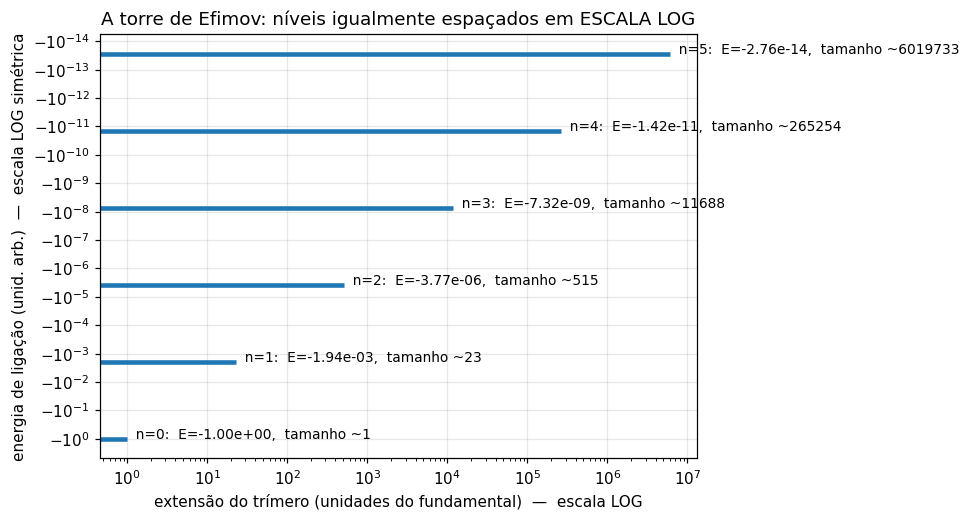

Em escala log os degraus são IGUAIS: essa regularidade é a assinatura de Efimov.


In [2]:
s0 = 1.00624
fator_E = np.exp(2*np.pi/s0)       # razão de energias entre trímeros vizinhos
fator_R = np.exp(np.pi/s0)         # razão de tamanhos
print(f'razão de energias : {fator_E:.2f}  (cada nível ~515x mais fraco)')
print(f'razão de tamanhos : {fator_R:.3f}  (cada trímero ~22,7x maior)')

# a torre: partindo de um trímero fundamental com E0 = -1 (unidade arbitrária)
n = np.arange(6)
E = -1.0 / fator_E**n
tamanho = fator_R**n

fig, ax = plt.subplots(figsize=(7, 5))
for i, (e, t) in enumerate(zip(E, tamanho)):
    ax.hlines(e, 0, t, lw=3)
    ax.annotate(f'  n={i}:  E={e:.2e},  tamanho ~{t:.0f}', (t, e), fontsize=9)
ax.set_yscale('symlog', linthresh=1e-14)
ax.set_xscale('log')
ax.set_xlabel('extensão do trímero (unidades do fundamental)  —  escala LOG')
ax.set_ylabel('energia de ligação (unid. arb.)  —  escala LOG simétrica')
ax.set_title('A torre de Efimov: níveis igualmente espaçados em ESCALA LOG')
plt.show()
print('Em escala log os degraus são IGUAIS: essa regularidade é a assinatura de Efimov.')

📊 **Como ler:** os dois eixos são logarítmicos. Cada barra é um
trímero: o de cima ($n=0$) é o mais fundo e compacto; cada seguinte é
515× mais raso e 22,7× maior. Em escala log ficam **igualmente
espaçados** — se você medir dois trímeros consecutivos num experimento e
a razão der ~515, você "viu" o Efimov.

Na prática só se observam os 2–3 primeiros: o seguinte já é maior que a
nuvem atômica inteira.

---
## 2. O cenário de Efimov (o desenho que organiza seu mestrado)

O diagrama clássico: eixo x = $1/a$ (o inverso do comprimento de
espalhamento!), eixo y = $K = \pm\sqrt{|E|}$ (assinada). Por que $1/a$?
Porque a unitariedade ($a=\pm\infty$) vira o **ponto zero** do eixo — e
as curvas dos trímeros atravessam esse zero suavemente:

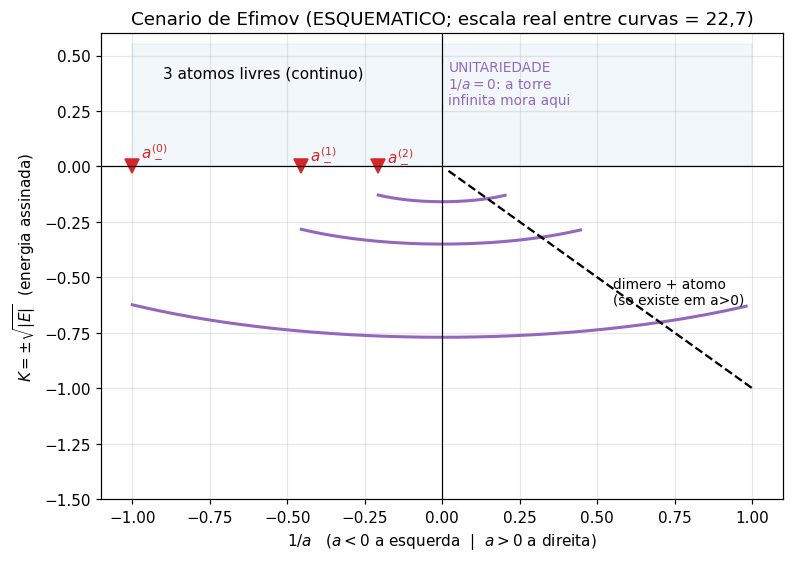

In [3]:
# desenho ESQUEMATICO do cenario de Efimov (sem escala real; escala
# comprimida para caberem 3 niveis -- no mundo real o fator e 22,7)
fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.linspace(-1.0, 1.0, 400)
lam = 2.2                                   # fator de escala ARTISTICO
for n in range(3):
    s = lam**(-n)
    xx = np.linspace(-s, s*0.98, 200)
    K = -s*0.65*np.sqrt(np.clip(1-(xx/s)**2*0.4, 0, None)) - 0.12*s
    ax.plot(xx, K, lw=2, color='tab:purple')
    ax.plot([-s], [0], 'v', color='tab:red', ms=9)
    ax.annotate(f'  $a_-^{{({n})}}$', (-s, 0.03*s+0.02), color='tab:red', fontsize=10)
# limiar atomo-dimero (so existe dimero em a>0): K = -1/a (esquematico)
xd = np.linspace(0.02, 1.0, 100)
ax.plot(xd, -xd, 'k--', lw=1.5)
ax.annotate('dimero + atomo\n(so existe em a>0)', (0.55, -0.62), fontsize=9)
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.fill_between(x, 0, 0.55, color='tab:blue', alpha=0.06)
ax.annotate('3 atomos livres (continuo)', (-0.9, 0.4), fontsize=10)
ax.annotate('UNITARIEDADE\n$1/a = 0$: a torre\ninfinita mora aqui', (0.02, 0.28),
            fontsize=9, color='tab:purple')
ax.set_xlabel('$1/a$   ($a<0$ a esquerda  |  $a>0$ a direita)')
ax.set_ylabel('$K = \\pm\\sqrt{|E|}$  (energia assinada)')
ax.set_title('Cenario de Efimov (ESQUEMATICO; escala real entre curvas = 22,7)')
ax.set_ylim(-1.5, 0.6)
plt.show()

📊 **Como ler o desenho** (é esquemático — a escala real entre curvas
consecutivas é 22,7, impossível de desenhar):

- **Acima de zero:** três átomos livres. **Curvas roxas:** os trímeros
  de Efimov (energia negativa = ligados).
- **Triângulos vermelhos ($a_-$):** onde cada trímero ENCOSTA no
  contínuo, do lado $a<0$. Nesses pontos o trímero se desfaz em 3 átomos
  → no experimento aparece um **pico de perda de átomos**. É ASSIM que
  se detecta Efimov: varrendo $a$ e procurando picos de perda em
  $a_-^{(0)}, a_-^{(1)} = 22{,}7\,a_-^{(0)}, \dots$ — no ³⁹K os DOIS mínimos
  medidos em $a>0$ deram razão $25(4)$, consistente com $22{,}7$!
- **Tracejada preta:** o limiar átomo+dímero (só existe dímero se $a>0$
  — como aprendemos!). Onde uma curva roxa encosta nela ($a_+$), o
  trímero vira átomo+dímero.
- **O eixo vertical $1/a = 0$** é a unitariedade: SÓ ali a torre é
  infinita.

**Seu mestrado em uma frase:** o que acontece com essas curvas quando o
sistema é espremido de 3D para 2D (confinamento anisotrópico)? Em 2D
puro NÃO existe efeito Efimov ($s_0$ vira imaginário) — então a torre
tem que morrer de algum jeito no meio do caminho. Como ela morre é a
pergunta.

---
## 3. O ³⁹K de verdade: girando o botão do laboratório

No laboratório da Patrícia ninguém gira "$v$" — gira-se o **campo
magnético $B$**. Perto de uma ressonância de Feshbach (D'Errico et al.
2007, os dados estão em `src/feshbach.py`):

$$a(B) = a_{bg}\left(1 - \frac{\Delta}{B - B_0}\right)$$

Para o estado $|F{=}1, m_F{=}1\rangle$ do ³⁹K: $B_0 = 402{,}50$ G,
$\Delta = -52{,}1$ G, $a_{bg} = -29\,a_0$ (refinados em Zaccanti et al. 2009). Vamos plotar e marcar os pontos
que interessam:

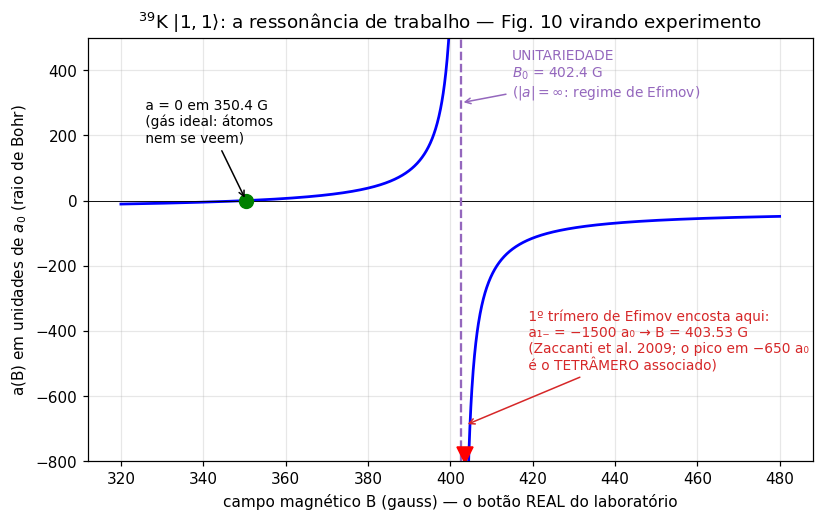

zero de a          : 350.4 G
unitariedade       : 402.5 G
1º trímero (a=-1500): 403.53 G  <- a ~1 G da unitariedade!
l_vdW do K         : 64.6 a0
|a1-|/l_vdW        : 23.2  (>>1: regime universal OK)


In [4]:
r = fb.RESSONANCIAS_39K['1,1'][1]          # a ressonância larga do |1,1>
B = np.linspace(320, 480, 2000)
a = fb.a_de_B(B, **r)
a[np.abs(B - r['B0']) < 0.4] = np.nan       # corta a divergência p/ plotar

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(B, a, 'b-', lw=1.8)
ax.axhline(0, color='k', lw=0.6)
ax.axvline(r['B0'], color='tab:purple', ls='--', lw=1.5)
z = fb.zero_de_a(r['B0'], r['Delta'])
ax.plot([z], [0], 'go', ms=9)
ax.annotate(f' a = 0 em {z:.1f} G\n (gás ideal: átomos\n nem se veem)', (z, 0),
            xytext=(325, 180), fontsize=9, arrowprops=dict(arrowstyle='->'))
ax.annotate('UNITARIEDADE\n$B_0$ = 402.4 G\n($|a| = \\infty$: regime de Efimov)',
            (r['B0'], 300), xytext=(415, 320), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='tab:purple'), color='tab:purple')
B_tri = fb.B_de_a(-1500.0, **r)   # a1- = -1500(90) a0 (Zaccanti 2009)
ax.plot([B_tri], [-780], 'rv', ms=11)   # marcador (fora do ylim se -1500)
ax.annotate(f' 1º trímero de Efimov encosta aqui:\n a₁₋ = −1500 a₀ → B = {B_tri:.2f} G\n (Zaccanti et al. 2009; o pico em −650 a₀\n é o TETRÂMERO associado)',
            (B_tri, -690), xytext=(418, -520), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='tab:red'), color='tab:red')
ax.set_ylim(-800, 500)
ax.set_xlabel('campo magnético B (gauss) — o botão REAL do laboratório')
ax.set_ylabel('a(B) em unidades de $a_0$ (raio de Bohr)')
ax.set_title('$^{39}$K $|1,1\\rangle$: a ressonância de trabalho — Fig. 10 virando experimento')
plt.show()

print(f"zero de a          : {z:.1f} G")
print(f"unitariedade       : {r['B0']} G")
print(f"1º trímero (a=-1500): {B_tri:.2f} G  <- a ~1 G da unitariedade!")
print(f"l_vdW do K         : {fb.comprimento_vdw_a0():.1f} a0")
print(f"|a1-|/l_vdW        : {1500/fb.comprimento_vdw_a0():.1f}  (>>1: regime universal OK)")

📊 **Como ler — e por que este gráfico é a Fig. 10 disfarçada:**

- **Eixo x:** o campo magnético em gauss — literalmente a corrente numa
  bobina do experimento. **Eixo y:** $a$ em raios de Bohr.
- A curva DIVERGE em $B_0 = 402{,}4$ G: é a MESMA parede da Fig. 10,
  mas agora o botão é real. À esquerda do zero (350,4 G) o gás é quase
  ideal; entre 350,4 e 402,4 G, $a>0$ cresce até $+\infty$; logo acima,
  $a<0$ gigante.
- **Triângulo vermelho:** com $a_1^- = -1500(90)\,a_0$ (medido), nosso
  módulo prevê o pico de perdas do primeiro trímero em $B \approx 403{,}5$ G — e o experimento ainda viu, em $\sim -650\,a_0$, o TETRÂMERO universal associado.
  Girar o campo 2 gauss acima da ressonância = pescar um trímero de Efimov.
- $|a_1^-|/\ell_{vdW} \approx 23 \gg 1$: o trímero é muito maior que o
  alcance real do potencial — exatamente a condição de universalidade
  que estudamos o notebook inteiro.

🔧 **MEXA AQUI:** troque `'1,1'` por `'1,-1'` (índice 2: a ressonância
de 560,7 G) e refaça as marcações. Ou pergunte: em que campo $a = +100\,a_0$
(bom pra fazer um BEC estável)? Use `fb.B_de_a(100, **r)`.

---
## Fechamento — o mapa do seu mestrado

| etapa | ferramenta | status |
|---|---|---|
| 2 corpos: $a$, $r_0$, unitariedade | este laboratório | ✅ dominado |
| botão real: $a(B)$ no ³⁹K | `src/feshbach.py` | ✅ v0 pronto |
| 3 corpos: torre de Efimov em 3D | hiperesférico / EFT | 🎯 próximo |
| confinamento 3D→2D: como a torre morre | EFT + VMC/DMC | 🎓 a dissertação |
| comparação com o experimento | dados da Patrícia | 🎓 a dissertação |

Referências de entrada (quando quiser): Efimov (1970); Braaten & Hammer,
Phys. Rep. 428, 259 (2006) — a bíblia da universalidade; Zaccanti et al.,
Nature Phys. 5, 586 (2009) — Efimov no ³⁹K; Naidon & Endo, Rep. Prog.
Phys. 80, 056001 (2017) — revisão moderna.